# Loan Portfolio Optimization Analysis

This notebook analyzes the optimized loan portfolio generated by the optimization model.

Objectives:
- Understand portfolio allocation
- Analyze sector exposure
- Visualize risk vs return characteristics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
file_path = "../Results/optimized_portfolio.csv"

df = pd.read_csv(file_path)

df.head()

,Loan_ID,Loan_Type,Industry,Rating,Spread,Default_Prob,Recovery_Rate,Utilization,WARF,Expected_Return,Portfolio_Weight
0,L1,Term Loan,Technology,BB,0.045,0.018,0.45,1.0,2000,0.03510,0.05
1,L2,Term Loan,Healthcare,B,0.055,0.025,0.40,1.0,3000,0.04000,0.05
2,L3,Term Loan,Energy,B,0.062,0.032,0.38,1.0,3000,0.04216,0.05
3,L4,Term Loan,Retail,CCC,0.078,0.055,0.32,1.0,4500,0.04060,0.05
4,L5,Term Loan,Technology,B,0.058,0.028,0.40,1.0,3000,0.04120,0.05


In [4]:
df_sorted = df.sort_values(by="Portfolio_Weight", ascending=False)

df_sorted.head(10)

,Loan_ID,Loan_Type,Industry,Rating,Spread,Default_Prob,Recovery_Rate,Utilization,WARF,Expected_Return,Portfolio_Weight
0,L1,Term Loan,Technology,BB,0.045,0.018,0.45,1.0,2000,0.03510,0.05
30,L31,Term Loan,Technology,B,0.056,0.029,0.39,1.0,3000,0.03831,0.05
32,L33,Term Loan,Energy,B,0.063,0.034,0.37,1.0,3000,0.04158,0.05
33,L34,Term Loan,Retail,CCC,0.079,0.058,0.31,1.0,4500,0.03898,0.05
1,L2,Term Loan,Healthcare,B,0.055,0.025,0.40,1.0,3000,0.04000,0.05
38,L39,Term Loan,Media,B,0.057,0.028,0.40,1.0,3000,0.04020,0.05
40,L41,Term Loan,Telecom,B,0.058,0.028,0.39,1.0,3000,0.04092,0.05
41,L42,Term Loan,Technology,BB,0.046,0.020,0.45,1.0,2000,0.03500,0.05
42,L43,Term Loan,Healthcare,B,0.060,0.030,0.38,1.0,3000,0.04140,0.05
43,L44,Term Loan,Energy,B,0.061,0.033,0.36,1.0,3000,0.03988,0.05


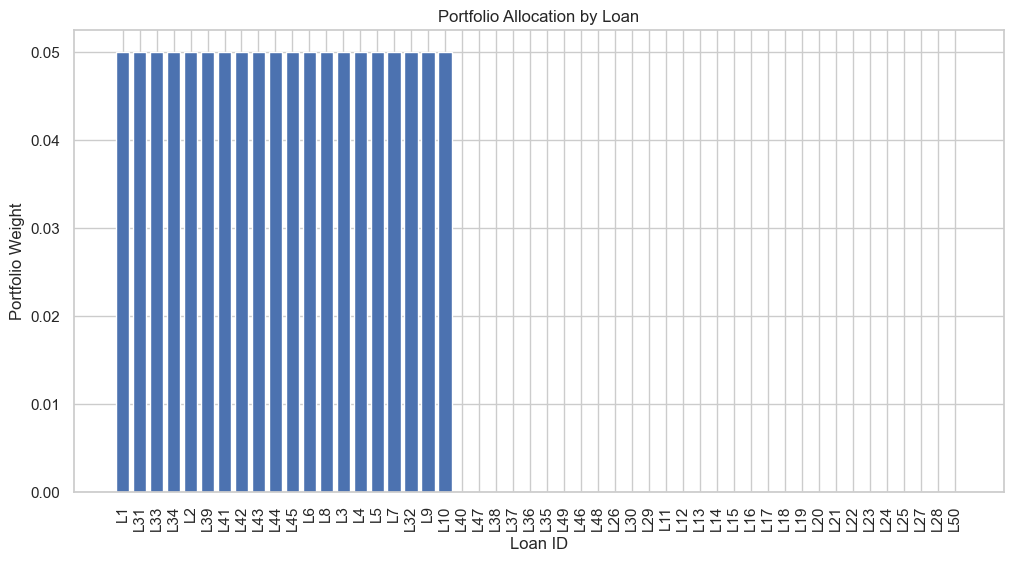

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(df_sorted["Loan_ID"], df_sorted["Portfolio_Weight"])

plt.xticks(rotation=90)
plt.title("Portfolio Allocation by Loan")
plt.xlabel("Loan ID")
plt.ylabel("Portfolio Weight")

plt.show()

In [12]:
sector_allocation = df.groupby("Industry")["Portfolio_Weight"].sum()

sector_allocation

Industry
Energy            0.20
Healthcare        0.20
Manufacturing     0.05
Media             0.10
Retail            0.15
Technology        0.20
Telecom           0.05
Transportation    0.05
Name: Portfolio_Weight, dtype: float64

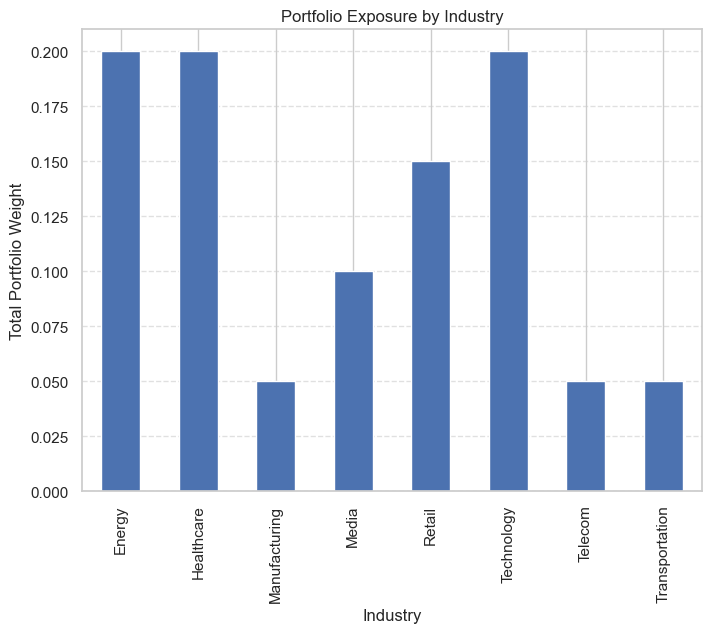

In [15]:
plt.figure(figsize=(8,6))

sector_allocation.plot(kind="bar")

plt.title("Portfolio Exposure by Industry")
plt.xlabel("Industry")
plt.ylabel("Total Portfolio Weight")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

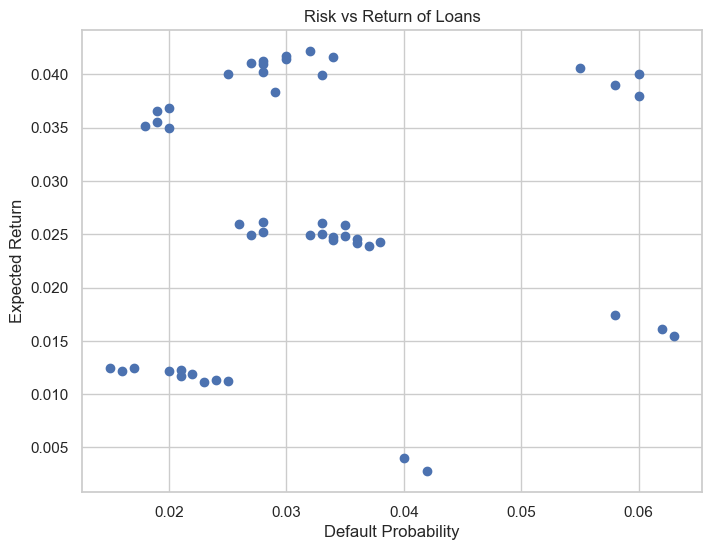

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(df["Default_Prob"], df["Expected_Return"])

plt.xlabel("Default Probability")
plt.ylabel("Expected Return")
plt.title("Risk vs Return of Loans")

plt.show()

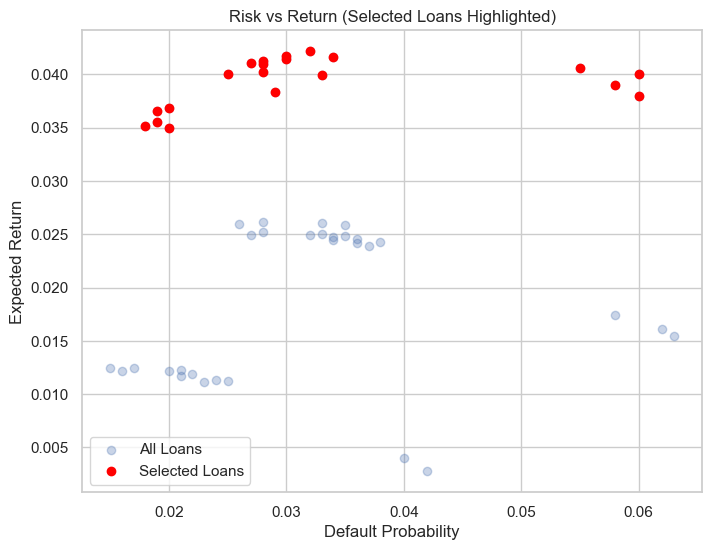

In [16]:
selected_loans = df[df["Portfolio_Weight"] > 0]

plt.figure(figsize=(8,6))

plt.scatter(df["Default_Prob"], df["Expected_Return"], alpha=0.3, label="All Loans")
plt.scatter(selected_loans["Default_Prob"], selected_loans["Expected_Return"], color="red", label="Selected Loans")

plt.xlabel("Default Probability")
plt.ylabel("Expected Return")
plt.title("Risk vs Return (Selected Loans Highlighted)")
plt.legend()

plt.show()

In [17]:
portfolio_return = (df["Expected_Return"] * df["Portfolio_Weight"]).sum()

print("Portfolio Expected Return:", round(portfolio_return,4))

Portfolio Expected Return: 0.0392


In [18]:
portfolio_risk = (df["Default_Prob"] * df["Portfolio_Weight"]).sum()

print("Portfolio Average Default Probability:", round(portfolio_risk,4))

Portfolio Average Default Probability: 0.0327


In [20]:
portfolio_warf = (df["WARF"] * df["Portfolio_Weight"]).sum()

print("Portfolio WARF:", round(portfolio_warf,2))

Portfolio WARF: 3050.0


In [21]:
top_loans = df.sort_values(by="Portfolio_Weight", ascending=False).head(10)

top_loans[["Loan_ID","Industry","Rating","Expected_Return","Portfolio_Weight"]]

,Loan_ID,Industry,Rating,Expected_Return,Portfolio_Weight
0,L1,Technology,BB,0.03510,0.05
30,L31,Technology,B,0.03831,0.05
32,L33,Energy,B,0.04158,0.05
33,L34,Retail,CCC,0.03898,0.05
1,L2,Healthcare,B,0.04000,0.05
38,L39,Media,B,0.04020,0.05
40,L41,Telecom,B,0.04092,0.05
41,L42,Technology,BB,0.03500,0.05
42,L43,Healthcare,B,0.04140,0.05
43,L44,Energy,B,0.03988,0.05


### Portfolio Summary

The optimized portfolio achieves an expected return of 3.92% with an average default probability of 3.27%. 

The portfolio maintains diversification across industries including Technology, Energy, and Healthcare while keeping credit risk within acceptable limits. 

The portfolio WARF of 3050 indicates moderate credit quality consistent with a diversified leveraged loan portfolio.